In [1]:
import numpy as np
import astropy.units as u
from astropy.io import fits
from matplotlib.colors import LogNorm
from matplotlib.patches import Rectangle, Circle
from pathlib import Path
from IPython.display import clear_output
from importlib import reload
from scipy.optimize import minimize

import poppy
import logging, sys
poppy_log = logging.getLogger('poppy')
poppy_log.setLevel('DEBUG')
logging.basicConfig(stream=sys.stdout, level=logging.INFO)
poppy_log.disabled = True

import warnings
warnings.filterwarnings("ignore")

from aefc_vortex.math_module import xp, xcipy, ensure_np_array
from aefc_vortex import utils
from aefc_vortex.imshows import imshow1, imshow2, imshow3, plot_data
from aefc_vortex import dm
from aefc_vortex import props
from aefc_vortex import aefc_2dm as aefc
import aefc_vortex.fresnel_2dm_96 as fresnel
import aefc_vortex.fraunhofer_2dm_96 as fraunhofer

Nwaves = 15
wavelength_c = 650e-9
bw = 0.10
waves = np.linspace(wavelength_c * (1-bw/2), wavelength_c * (1+bw/2), Nwaves )
bandpasses = waves.reshape(3,5)
print(bandpasses)

Nwaves_per_bp = bandpasses.shape[1]
control_waves = bandpasses[:, Nwaves_per_bp//2]
print(control_waves)

# dm1_flat = xp.rot90(xp.rot90( utils.load_fits('data/dm1_flat_command_96.fits') ))
# M = fraunhofer.MODEL()
# dm1_flat += 1e-9*xp.random.randn(M.Nact,M.Nact) * M.dm_mask

/home/kianmilani/Projects/adefc-vortex/aefc_vortex
[[6.17500000e-07 6.22142857e-07 6.26785714e-07 6.31428571e-07
  6.36071429e-07]
 [6.40714286e-07 6.45357143e-07 6.50000000e-07 6.54642857e-07
  6.59285714e-07]
 [6.63928571e-07 6.68571429e-07 6.73214286e-07 6.77857143e-07
  6.82500000e-07]]
[6.26785714e-07 6.50000000e-07 6.73214286e-07]


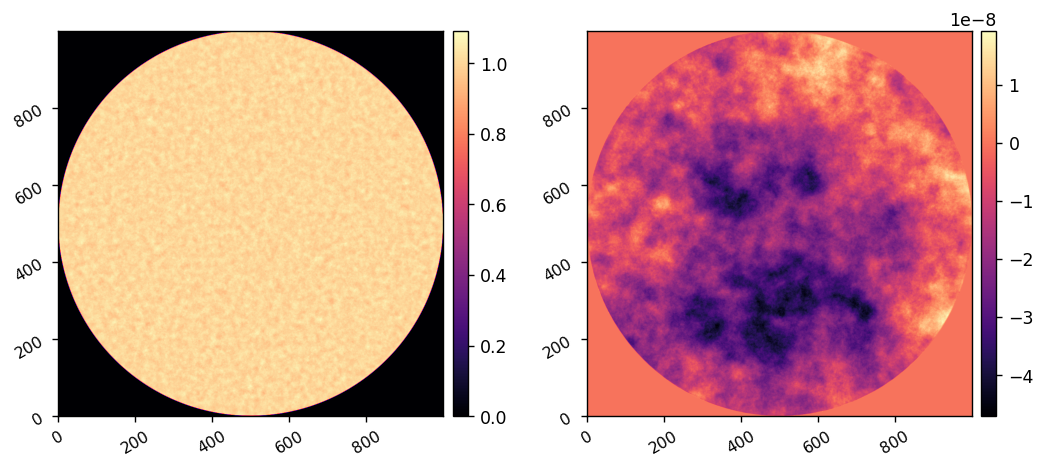

In [2]:
reload(fresnel)
I = fresnel.CORO()
I.use_opds = True

AMP, OPD = I.calc_pupil()
imshow2(AMP, OPD)

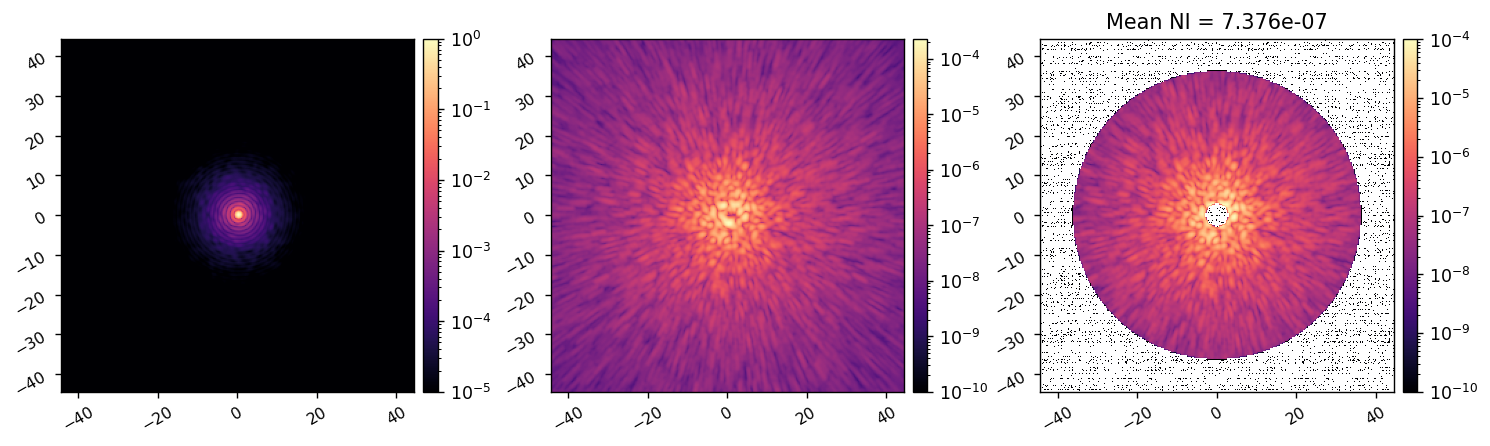

In [3]:
reload(fresnel)
I = fresnel.CORO()
I.use_opds = True
I.bandpasses = bandpasses

I.use_vortex = False
ref_psf = I.snap()
I.Imax_ref = xp.max(ref_psf)
ref_psf /= I.Imax_ref
I.use_vortex = True
ref_coro_im = I.snap()

reload(utils)
I.reset_dms()
iwa = 3
owa = 36
rot = 0
control_mask = utils.create_annular_focal_plane_mask(I.npsf, I.psf_pixelscale_lamDc, irad=iwa, orad=owa, edge=None, rotation=rot)
# control_mask = utils.create_annular_focal_plane_mask(I.npsf, I.psf_pixelscale_lamDc, irad=iwa, orad=owa, edge=iwa, rotation=rot)
mean_ni0 = xp.mean(ref_coro_im[control_mask])

imshow3(
    ref_psf, ref_coro_im, ref_coro_im*control_mask,
    '', '', f'Mean NI = {mean_ni0:.3e}',
    pxscl=I.psf_pixelscale_lamDc, 
    lognorm=True, vmin1=1e-5, vmin2=1e-10, vmin3=1e-10,
)


In [14]:
mem_usage_from_fresnel_model = 3.794

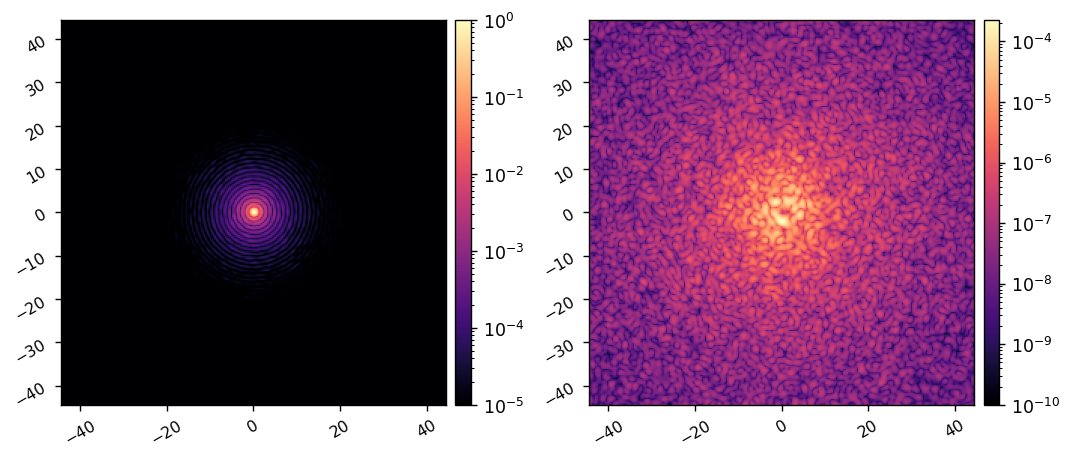

In [5]:
reload(fraunhofer)
M = fraunhofer.MODEL()
M.AMP = AMP
M.OPD = OPD

M.flip_dm = True
M.flip_lyot = True

acts = xp.zeros(M.Nacts)

model_psf = xp.abs( M.forward(acts, M.wavelength_c, use_vortex=0) )**2
M.setattr('Imax_ref', xp.max(model_psf))
model_psf /= M.Imax_ref

model_coro_im = xp.abs( M.forward(acts, M.wavelength_c, use_vortex=1) )**2

imshow2(model_psf, model_coro_im,
        pxscl=M.psf_pixelscale_lamDc, lognorm=True, vmin1=1e-5, vmin2=1e-10)

In [8]:
mem_usage_with_forward_model = 6.610

In [7]:
I.reset_dms()
data = {
    # 'ref_im':ref_coro_im, 
    'images':[ref_coro_im],
    'efields':[],
    'dm1_commands':[],
    'del_dm1_commands':[],
    'dm2_commands':[],
    'del_dm2_commands':[],
    'reg_conds':[],
    'bfgs_tols':[],
    'pixelscale':I.psf_pixelscale_lamDc,
    'control_mask':control_mask, 
}

In [12]:
mem_usage_while_doing_aefc = 8.530

Computing E-field with model ...
Computing EFC command with L-BFGS
RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =        14736     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  1.00000D+00    |proj g|=  9.68223D+05


 This problem is unconstrained.



At iterate    1    f=  9.99038D-01    |proj g|=  7.99430D+05

At iterate    2    f=  9.94436D-01    |proj g|=  4.38193D+05

At iterate    3    f=  9.92809D-01    |proj g|=  4.42950D+05

At iterate    4    f=  9.88640D-01    |proj g|=  5.55240D+05

At iterate    5    f=  9.87940D-01    |proj g|=  4.65035D+05

At iterate    6    f=  9.84576D-01    |proj g|=  4.01515D+05

At iterate    7    f=  9.82189D-01    |proj g|=  4.89851D+05

At iterate    8    f=  9.80474D-01    |proj g|=  5.37944D+05

At iterate    9    f=  9.77819D-01    |proj g|=  3.19772D+05

At iterate   10    f=  9.75988D-01    |proj g|=  4.42656D+05

At iterate   11    f=  9.73027D-01    |proj g|=  3.85741D+05

At iterate   12    f=  9.72451D-01    |proj g|=  9.77000D+05

At iterate   13    f=  9.69801D-01    |proj g|=  3.33489D+05

At iterate   14    f=  9.68450D-01    |proj g|=  2.94767D+05

At iterate   15    f=  9.67008D-01    |proj g|=  4.54842D+05

At iterate   16    f=  9.66171D-01    |proj g|=  7.64100D+05

At iter

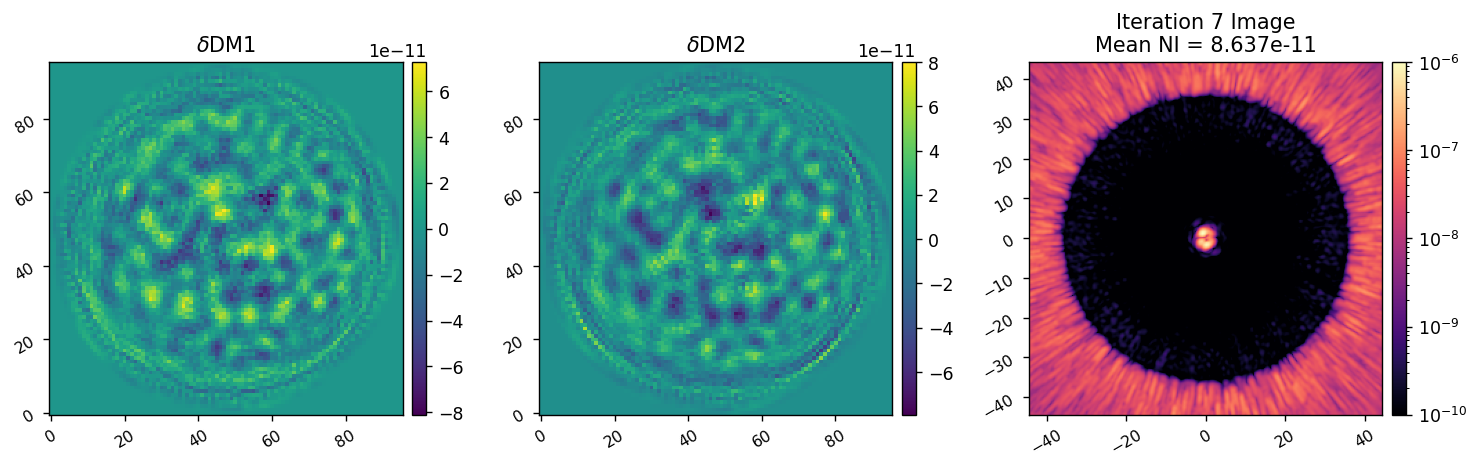

Computing E-field with model ...
Computing EFC command with L-BFGS
RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =        14736     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  1.00000D+00    |proj g|=  6.95219D+05


 This problem is unconstrained.



At iterate    1    f=  9.99661D-01    |proj g|=  5.82137D+05

At iterate    2    f=  9.97951D-01    |proj g|=  2.81673D+05

At iterate    3    f=  9.97247D-01    |proj g|=  2.93637D+05

At iterate    4    f=  9.95818D-01    |proj g|=  4.00561D+05

At iterate    5    f=  9.95127D-01    |proj g|=  3.21595D+05

At iterate    6    f=  9.94266D-01    |proj g|=  2.23927D+05

At iterate    7    f=  9.93133D-01    |proj g|=  3.02397D+05

At iterate    8    f=  9.93121D-01    |proj g|=  6.56032D+05

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
14736      8     18      1     0     0   6.560D+05   9.931D-01
  F =  0.993121241466

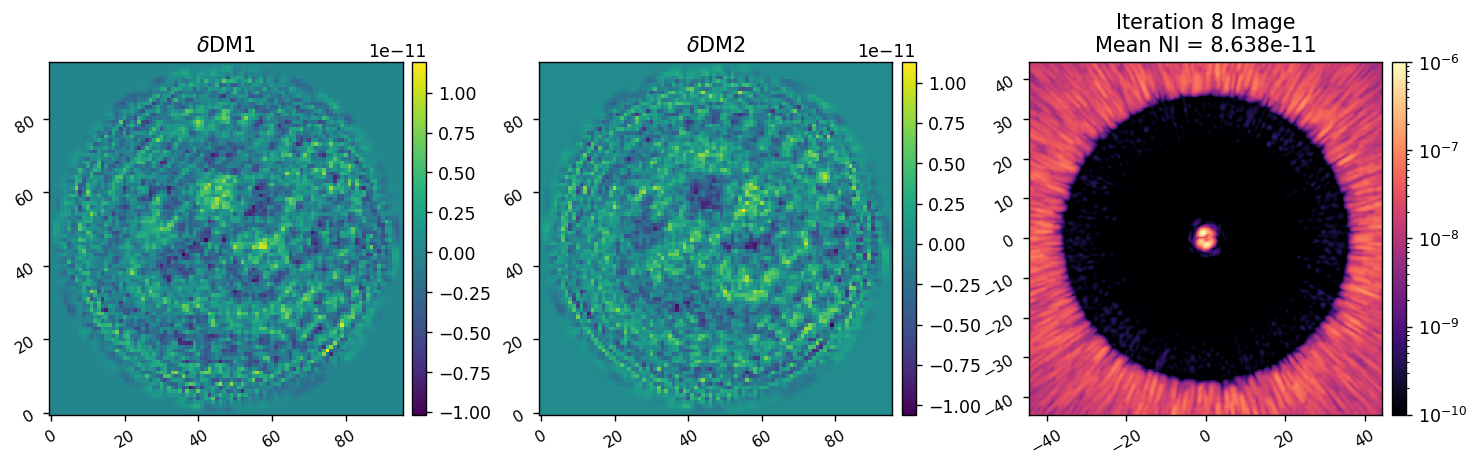

Computing E-field with model ...
Computing EFC command with L-BFGS
RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =        14736     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  1.00000D+00    |proj g|=  6.54620D+05


 This problem is unconstrained.



At iterate    1    f=  9.99718D-01    |proj g|=  5.68614D+05

At iterate    2    f=  9.98621D-01    |proj g|=  1.90819D+05

At iterate    3    f=  9.98411D-01    |proj g|=  2.06234D+05

At iterate    4    f=  9.97294D-01    |proj g|=  2.94437D+05

At iterate    5    f=  9.96577D-01    |proj g|=  3.62665D+05

At iterate    6    f=  9.96248D-01    |proj g|=  4.48189D+05

At iterate    7    f=  9.95676D-01    |proj g|=  1.73536D+05

At iterate    8    f=  9.95384D-01    |proj g|=  1.98386D+05

At iterate    9    f=  9.94755D-01    |proj g|=  3.33002D+05

At iterate   10    f=  9.93783D-01    |proj g|=  5.30506D+05

At iterate   11    f=  9.92754D-01    |proj g|=  4.45712D+05

At iterate   12    f=  9.91690D-01    |proj g|=  3.05589D+05

At iterate   13    f=  9.91232D-01    |proj g|=  6.52010D+05

At iterate   14    f=  9.90394D-01    |proj g|=  5.60435D+05

At iterate   15    f=  9.89329D-01    |proj g|=  5.03193D+05

At iterate   16    f=  9.88931D-01    |proj g|=  4.80254D+05

At iter

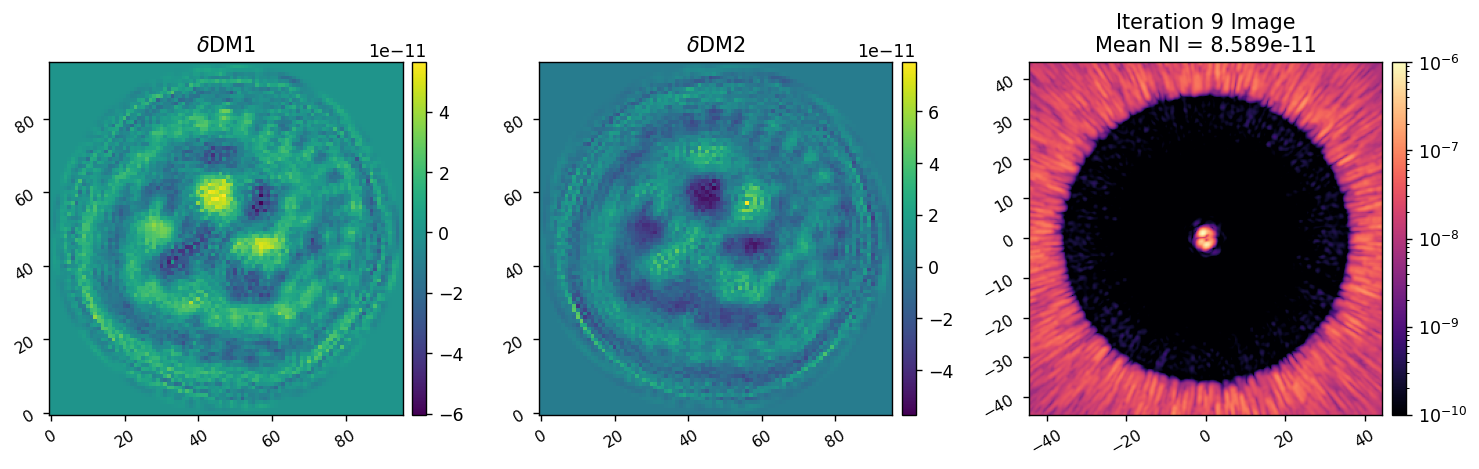

In [11]:
reload(fraunhofer)
reload(aefc)

bfgs_tol = 1e-2
bfgs_tol = 1e-3
bfgs_tol = 1e-4
# bfgs_tol = 1e-5
# bfgs_tol = 1e-10

bfgs_opts = {
    'disp':True,
    'maxls':10, 
    'maxiter':50,
    # 'ftol':1e-6,
    # 'gtol':1e-6,
}

data = aefc.run_bb(
    I, 
    M, 
    fraunhofer.val_and_grad_bb, 
    control_mask, 
    data,
    # Nitr=3, reg_cond=1e-1,
    # Nitr=3, reg_cond=1e-2,
    Nitr=3, reg_cond=1e-3,
    # Nitr=3, reg_cond=1e-4,
    # Nitr=3, reg_cond=1e-5,
    # Nitr=3, reg_cond=1e-6,
    # Nitr=3, reg_cond=1e-7,
    # Nitr=3, reg_cond=1e-8,
    # Nitr=3, reg_cond=1e-12,
    # weights=np.array([20,1,20]), 
    bfgs_tol=bfgs_tol,
    bfgs_opts=bfgs_opts,
    gain=1,
)



In [17]:
print(mem_usage_from_fresnel_model, mem_usage_with_forward_model, mem_usage_while_doing_aefc)

3.794 6.61 8.53


In [18]:
aefc_mem_usage = mem_usage_while_doing_aefc - mem_usage_with_forward_model
print(aefc_mem_usage)

aefc_mem_usage = mem_usage_while_doing_aefc - mem_usage_from_fresnel_model
print(aefc_mem_usage)

1.919999999999999
4.735999999999999


In [24]:
from datetime import datetime
today = int(datetime.today().strftime('%Y%m%d'))
now = datetime.now().strftime('%Y%m%d%H%M%S')
utils.save_pickle(f'/npool/nvme/kianmilani/aefc-vortex-data/fresnel_96_aefc_run_{now}.pkl', data)

Saved data to:  /npool/nvme/kianmilani/aefc-vortex-data/fresnel_96_aefc_run_20250424110931.pkl
